In [36]:
import zuko
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
from torch.distributions import Independent, StudentT
from torch.utils.data import DataLoader, TensorDataset
from zuko.lazy import LazyDistribution
from L05.da_map.da_helper import get_H_HA
import torch

## Load in training data

In [37]:
cwd = Path.cwd().resolve()
repo_root = cwd
while not (repo_root / 'modular_da').exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda:3


In [38]:
train_size = 4000000
val_size = 500_000
test_size = 100_000
spatial_index = 270
obs_stride = 9
window_radius = 50

data_dir = repo_root / 'coupling_lorenz' / 'data'
stx = np.load(data_dir / 'stx1.npy')
sty = np.load(data_dir / 'sty1.npy')

# Sum |small-scale| over the current step and previous 4 steps.
c = np.cumsum(np.abs(sty), axis=1)
cpad = np.concatenate([np.zeros_like(c[:, :1]), c], axis=1)
stysm = cpad[:, 5:] - cpad[:, :-5]

H, HA = get_H_HA(480, obs_stride)
obs = HA @ stysm

model_data = stx[:, 4:]

# Use only the current large-scale stencil to model p(y | x_t).
X = model_data[spatial_index - window_radius : spatial_index + window_radius + 1].T
obs_index = np.where(np.arange(0, 480, 1)[::obs_stride] == spatial_index)[0][0]
Y_clean = obs[obs_index, :].reshape(-1, 1)

# Train directly on noisy observations so the flow learns a non-Gaussian target.
train_obs_noise_std_raw = 0.15
train_obs_noise_mode_offset_raw = 0.3
train_obs_noise_left_weight = 0.5
rng = np.random.default_rng(0)
mix_draw = rng.random(Y_clean.shape)
mode_loc = np.where(
    mix_draw < train_obs_noise_left_weight,
    -train_obs_noise_mode_offset_raw,
    train_obs_noise_mode_offset_raw,
)

obs_noise = mode_loc + rng.normal(loc=0.0, scale=train_obs_noise_std_raw, size=Y_clean.shape)
obs_noise = rng.normal(loc=0.0, scale=0.3, size=Y_clean.shape)

Y_obs = Y_clean #+ obs_noise

X_tensor_raw = torch.tensor(X, dtype=torch.float32)
y_tensor_raw = torch.tensor(Y_obs, dtype=torch.float32)

X_train_raw = X_tensor_raw[:train_size]
y_train_raw = y_tensor_raw[:train_size]

x_mean = X_train_raw.mean()
x_std = X_train_raw.std().clamp_min(1e-6)
y_mean = y_train_raw.mean(dim=0, keepdim=True)
y_std = y_train_raw.std(dim=0, keepdim=True).clamp_min(1e-6)

X_tensor = (X_tensor_raw - x_mean) / x_std
y_tensor = (y_tensor_raw - y_mean) / y_std

X_train_tensor = X_tensor[:train_size]
y_train_tensor = y_tensor[:train_size]
X_val_tensor = X_tensor[train_size : train_size + val_size]
y_val_tensor = y_tensor[train_size : train_size + val_size]
X_test_tensor = X_tensor[train_size + val_size : train_size + val_size + test_size]
y_test_tensor = y_tensor[train_size + val_size : train_size + val_size + test_size]

batch_size = 4096

train_x = X_train_tensor
train_y = y_train_tensor
val_x = X_val_tensor
val_y = y_val_tensor
test_x = X_test_tensor
test_y = y_test_tensor

train_loader = DataLoader(
    TensorDataset(train_x, train_y),
    batch_size=batch_size,
    shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(val_x, val_y),
    batch_size=batch_size,
    shuffle=False,
)
test_loader = DataLoader(
    TensorDataset(test_x, test_y),
    batch_size=batch_size,
    shuffle=False,
)

print('train_x:', train_x.shape)
print('train_y:', train_y.shape)
print('val_x:  ', val_x.shape)
print('val_y:  ', val_y.shape)
print('test_x: ', test_x.shape)
print('test_y: ', test_y.shape)


train_x: torch.Size([4000000, 101])
train_y: torch.Size([4000000, 1])
val_x:   torch.Size([500000, 101])
val_y:   torch.Size([500000, 1])
test_x:  torch.Size([100000, 101])
test_y:  torch.Size([100000, 1])


## Define Flow Model
- note: student T is used as the base to prevent help encourage better tail predictions

In [39]:

class StudentTBase(LazyDistribution):
    def __init__(self, features: int, df: float = 5.0):
        super().__init__()
        self.loc = torch.nn.Parameter(torch.zeros(features))
        self.log_scale = torch.nn.Parameter(torch.zeros(features))
        self.log_df = torch.nn.Parameter(torch.full((features,), np.log(df)))

    def forward(self, c=None):
        return Independent(
            StudentT(df=self.log_df.exp(), loc=self.loc, scale=self.log_scale.exp()),
            1,
        )

flow_model = zuko.flows.NSF(
    1,
    2 * window_radius + 1,
    transforms=3,
    hidden_features=[128] * 4,
).to(device)
flow_model.base = StudentTBase(1, 3).to(device)
flow = flow_model

In [40]:
# checkpointing directory
best_model_path = repo_root / 'modular_da' / 'spline_normalizing' / 'bimodal_nohistory_checkpoints' / 'hw3.pt'
best_model_path.parent.mkdir(parents=True, exist_ok=True)

## Train Model

epoch 1/50, train_loss=0.4994, val_loss=0.4179
epoch 2/50, train_loss=0.3308, val_loss=0.2821
epoch 3/50, train_loss=0.2638, val_loss=0.2432
epoch 4/50, train_loss=0.2273, val_loss=0.2108
epoch 5/50, train_loss=0.2021, val_loss=0.1988
epoch 6/50, train_loss=0.1827, val_loss=0.1746
epoch 7/50, train_loss=0.1670, val_loss=0.1626
epoch 8/50, train_loss=0.1527, val_loss=0.1456
epoch 9/50, train_loss=0.1412, val_loss=0.1421
epoch 10/50, train_loss=0.1296, val_loss=0.1267
epoch 11/50, train_loss=0.1191, val_loss=0.1105
epoch 12/50, train_loss=0.1102, val_loss=0.1240
epoch 13/50, train_loss=0.1020, val_loss=0.1065
epoch 14/50, train_loss=0.0945, val_loss=0.1118
epoch 15/50, train_loss=0.0877, val_loss=0.0889
epoch 16/50, train_loss=0.0809, val_loss=0.0804
epoch 17/50, train_loss=0.0758, val_loss=0.0731
epoch 18/50, train_loss=0.0705, val_loss=0.0758
epoch 19/50, train_loss=0.0658, val_loss=0.0664
epoch 20/50, train_loss=0.0602, val_loss=0.0617
epoch 21/50, train_loss=0.0559, val_loss=0.0638
e

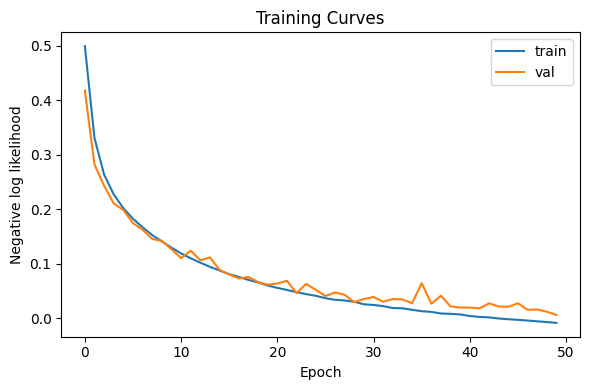

In [41]:
optimizer = torch.optim.AdamW(flow_model.parameters(), lr=1e-3)
epochs = 50
train_losses = []
val_losses = []
best_val_loss = float('inf')

for epoch in range(epochs):
    flow_model.train()
    total_train_loss = 0.0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        loss = -flow_model(x).log_prob(y)  # -log p(y | x)
        loss = loss.mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    mean_train_loss = total_train_loss / len(train_loader)
    train_losses.append(mean_train_loss)

    flow_model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)

            loss = -flow_model(x).log_prob(y)
            loss = loss.mean()
            total_val_loss += loss.item()

    mean_val_loss = total_val_loss / len(val_loader)
    val_losses.append(mean_val_loss)

    if mean_val_loss < best_val_loss:
        best_val_loss = mean_val_loss
        torch.save(
            {
                'model_state_dict': flow_model.state_dict(),
                'x_mean': x_mean.detach().cpu(),
                'x_std': x_std.detach().cpu(),
                'y_mean': y_mean.detach().cpu(),
                'y_std': y_std.detach().cpu(),
            },
            best_model_path,
        )
        

    print(
        f'epoch {epoch + 1}/{epochs}, train_loss={mean_train_loss:.4f}, val_loss={mean_val_loss:.4f}'
    )

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('Epoch')
plt.ylabel('Negative log likelihood')
plt.title('Training Curves')
plt.legend()
plt.tight_layout()
plt.show()


In [42]:
# checkpointing directory
best_model_path = repo_root / 'modular_da' / 'spline_normalizing' / 'bimodal_nohistory_checkpoints' / 'hw3.pt'
best_model_path.parent.mkdir(parents=True, exist_ok=True)

## Testing

### Single sample

In [43]:
# load model and normalization statistics from checkpoint
checkpoint = torch.load(best_model_path)
flow_model.load_state_dict(checkpoint['model_state_dict'])
x_mean = checkpoint['x_mean']
x_std = checkpoint['x_std']
y_mean = checkpoint['y_mean']
y_std = checkpoint['y_std']

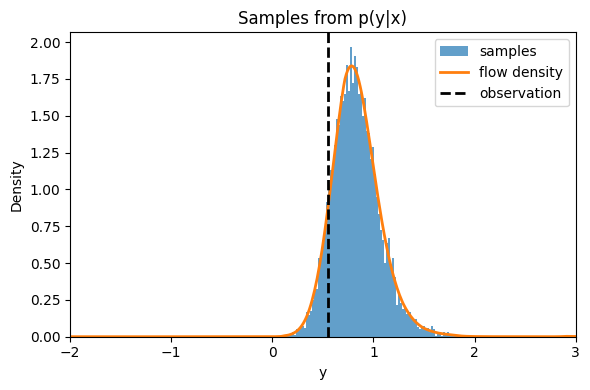

In [44]:
# Sample from the learned conditional model for one test input.
index = 15
x_star = test_x[index:index + 1].to(device)
y_star = test_y[index:index + 1]
y_samples = flow_model(x_star).sample((10000,))

y_star = torch.tensor(Y_clean[train_size + val_size + index], dtype=torch.float32)
y_samples_raw = y_samples.cpu() * y_std + y_mean
y_star_raw = y_star

dist = flow_model(x_star)
raw_min, raw_max = -2.0, 3.0
y_grid_raw = torch.linspace(raw_min, raw_max, 400)
y_grid = (y_grid_raw.unsqueeze(-1) - y_mean.cpu()) / y_std.cpu()

with torch.no_grad():
    log_density = dist.log_prob(y_grid.to(device))

density_raw = torch.exp(log_density).cpu() / float(y_std.squeeze())


plt.figure(figsize=(6, 4))
plt.hist(y_samples_raw[:, 0].numpy(), bins=300, density=True, alpha=0.7, label='samples')
plt.plot(y_grid_raw.numpy(), density_raw.numpy(), color='C1', linewidth=2, label='flow density')
plt.axvline(y_star_raw.item(), color='black', linestyle='--', linewidth=2, label='observation')
plt.xlabel('y')
plt.ylabel('Density')
plt.title('Samples from p(y|x)')
plt.legend()
plt.xlim(raw_min, raw_max)
plt.tight_layout()
plt.show()



### Rank Hist

In [49]:
eval_size = 200000
ensemble_size = 30
sample_batch_size = 250

eval_x = test_x[:eval_size]
eval_y = test_y[:eval_size]
sample_batches = []

with torch.no_grad():
    for start in range(0, eval_size, sample_batch_size):
        xb = eval_x[start:start + sample_batch_size].to(device)
        yb = flow_model(xb).sample((ensemble_size,)).cpu()
        sample_batches.append(yb)

rank_samples = torch.cat(sample_batches, dim=1).squeeze(-1).numpy()
rank_samples = rank_samples * float(y_std.squeeze()) + float(y_mean.squeeze())
eval_obs = (eval_y * y_std + y_mean).squeeze(-1).numpy()


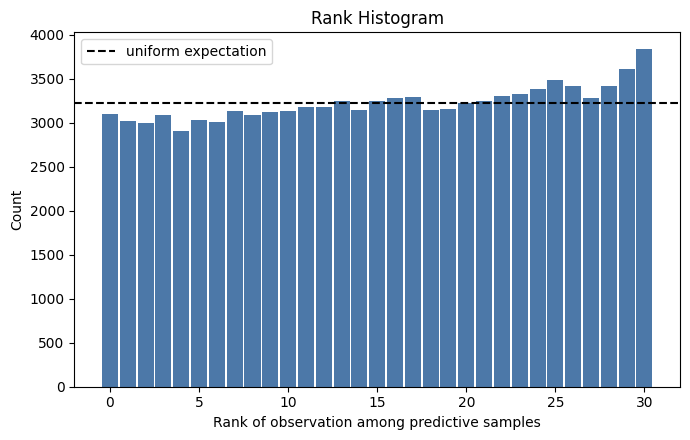

eval_size=200000
ensemble_size=30
expected count per bin=3225.8
rank count std=188.2


In [50]:

ranks = np.sum(rank_samples < eval_obs[None, :], axis=0)
rank_counts = np.bincount(ranks, minlength=ensemble_size + 1)
expected = len(eval_obs) / (ensemble_size + 1)

plt.figure(figsize=(7, 4.5))
plt.bar(np.arange(ensemble_size + 1), rank_counts, width=0.9, color='#4C78A8')
plt.axhline(expected, color='black', linestyle='--', linewidth=1.5, label='uniform expectation')
plt.xlabel('Rank of observation among predictive samples')
plt.ylabel('Count')
plt.title(f'Rank Histogram')
plt.legend()
plt.tight_layout()
plt.show()

print(f'eval_size={eval_size}')
print(f'ensemble_size={ensemble_size}')
print(f'expected count per bin={expected:.1f}')
print(f'rank count std={rank_counts.std():.1f}')


### Confidence intervals
- This plot compares the observed distribution of y to the model’s predictive distribution across bins of similar predicted mean. We hope to see model and observed means as well as interval bands closely align. 

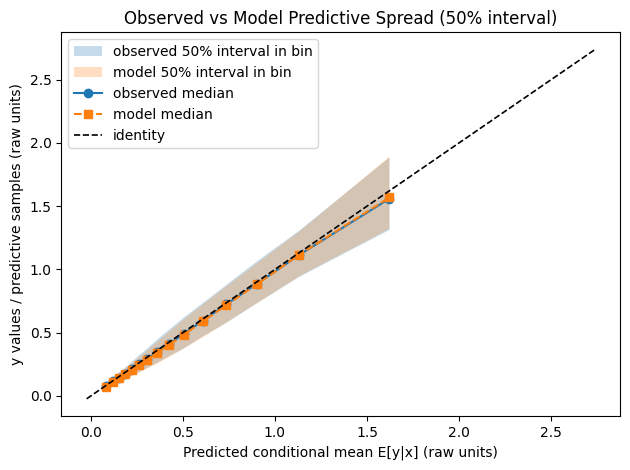

Using observations: observed
Bin counts: [6667 6667 6666 6667 6666 6667 6667 6666 6667 6666 6667 6667 6666 6667
 6667]
50% coverage by bin: [0.45717714 0.46587671 0.45274527 0.45762712 0.46444644 0.46257687
 0.46467677 0.46339634 0.4639268  0.46474647 0.47697615 0.46647668
 0.46969697 0.46692665 0.45552722]
Mean 50% coverage: 0.46351997431631564


In [47]:
import numpy as np
import matplotlib.pyplot as plt

y = np.asarray(eval_obs).ravel()
samples = np.asarray(rank_samples)

def plot_confidence_interval_summary(coverage_level=0.50, n_bins=15, ax=None, show_legend=True):
    pred = samples.mean(axis=0).ravel()

    alpha = (1 - coverage_level) / 2
    q_lo = alpha
    q_hi = 1 - alpha
    label_pct = int(coverage_level * 100)

    # threshold values that split the sorted predicted means into bins of about equal size
    bins = np.quantile(pred, np.linspace(0, 1, n_bins + 1))
    bin_id = np.digitize(pred, bins[1:-1])

    bin_pred = []
    obs_qlo = []
    obs_q50 = []
    obs_qhi = []
    mod_qlo = []
    mod_q50 = []
    mod_qhi = []
    coverage_by_bin = []
    counts = []

    for k in range(n_bins):
        mask = bin_id == k
        if mask.sum() == 0:
            continue

        bin_pred.append(pred[mask].mean())

        # observed distribution within this predicted-mean bin
        obs_qlo.append(np.quantile(y[mask], q_lo))
        obs_q50.append(np.quantile(y[mask], 0.50))
        obs_qhi.append(np.quantile(y[mask], q_hi))

        # model predictive distribution within this predicted-mean bin
        s_bin = samples[:, mask].reshape(-1)
        mod_qlo.append(np.quantile(s_bin, q_lo))
        mod_q50.append(np.quantile(s_bin, 0.50))
        mod_qhi.append(np.quantile(s_bin, q_hi))

        # casewise coverage
        lo_i = np.quantile(samples[:, mask], q_lo, axis=0)
        hi_i = np.quantile(samples[:, mask], q_hi, axis=0)
        coverage_by_bin.append(np.mean((y[mask] >= lo_i) & (y[mask] <= hi_i)))
        counts.append(mask.sum())

    bin_pred = np.array(bin_pred)
    obs_qlo = np.array(obs_qlo)
    obs_q50 = np.array(obs_q50)
    obs_qhi = np.array(obs_qhi)
    mod_qlo = np.array(mod_qlo)
    mod_q50 = np.array(mod_q50)
    mod_qhi = np.array(mod_qhi)
    coverage_by_bin = np.array(coverage_by_bin)
    counts = np.array(counts)

    lims = [
        float(min(obs_qlo.min(), mod_qlo.min(), pred.min())),
        float(max(obs_qhi.max(), mod_qhi.max(), pred.max()))
    ]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6.4, 4.8))

    ax.fill_between(
        bin_pred, obs_qlo, obs_qhi,
        alpha=0.25,
        label=f"observed {label_pct}% interval in bin"
    )
    ax.fill_between(
        bin_pred, mod_qlo, mod_qhi,
        alpha=0.25,
        label=f"model {label_pct}% interval in bin"
    )
    ax.plot(bin_pred, obs_q50, "o-", label="observed median")
    ax.plot(bin_pred, mod_q50, "s--", label="model median")
    ax.plot(lims, lims, "k--", linewidth=1.2, label="identity")
    ax.set_xlabel("Predicted conditional mean E[y|x] (raw units)")
    ax.set_ylabel("y values / predictive samples (raw units)")
    ax.set_title(f"Observed vs Model Predictive Spread ({label_pct}% interval)")
    if show_legend:
        ax.legend()

    return {
        "bin_pred": bin_pred,
        "counts": counts,
        "coverage_by_bin": coverage_by_bin,
        "mean_coverage": coverage_by_bin.mean(),
        "label_pct": label_pct,
    }

result = plot_confidence_interval_summary(coverage_level=0.50, n_bins=15)
plt.tight_layout()
plt.show()

print("Using observations:", "observed")
print("Bin counts:", result["counts"])
print(f"{result['label_pct']}% coverage by bin:", result["coverage_by_bin"])
print(f"Mean {result['label_pct']}% coverage:", result["mean_coverage"])


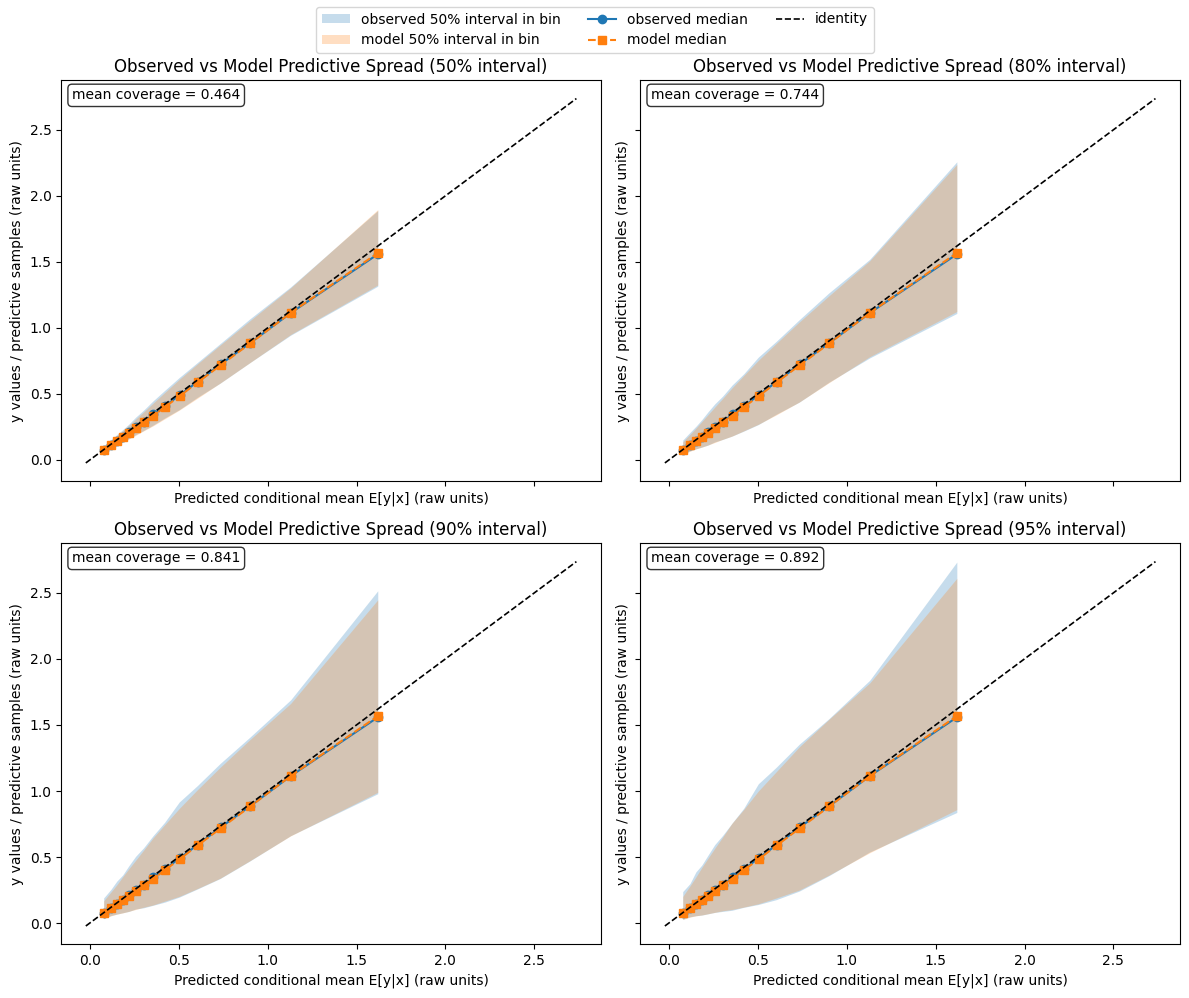

In [48]:
coverage_levels = [0.50, 0.80, 0.90, 0.95]
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

subplot_results = []
for ax, level in zip(axes.flat, coverage_levels):
    res = plot_confidence_interval_summary(
        coverage_level=level,
        n_bins=15,
        ax=ax,
        show_legend=False,
    )
    subplot_results.append(res)
    ax.text(
        0.02,
        0.98,
        f"mean coverage = {res['mean_coverage']:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


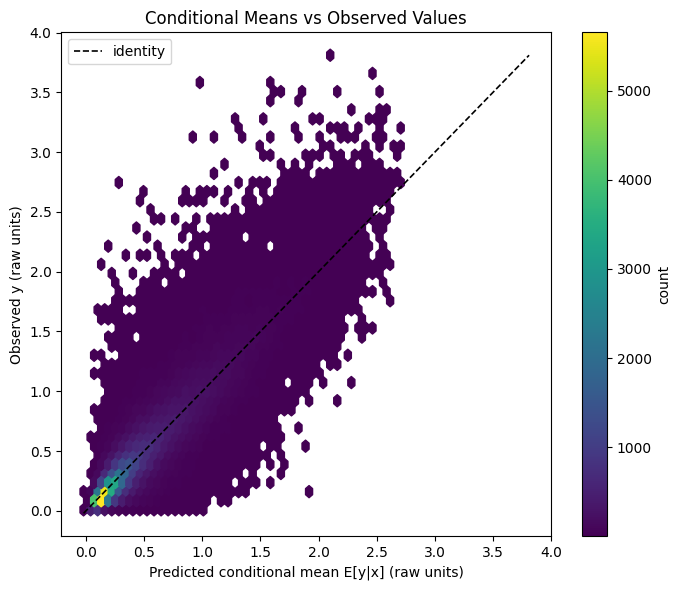

In [52]:
pred = np.asarray(rank_samples).mean(axis=0)
obs = np.asarray(eval_obs).ravel()

plt.figure(figsize=(7, 6))
hb = plt.hexbin(pred, obs, gridsize=45, mincnt=1, cmap="viridis")
plt.colorbar(hb, label="count")

line_min = min(pred.min(), obs.min())
line_max = max(pred.max(), obs.max())
plt.plot([line_min, line_max], [line_min, line_max], "k--", linewidth=1.2, label="identity")

plt.xlabel("Predicted conditional mean E[y|x] (raw units)")
plt.ylabel("Observed y (raw units)")
plt.title("Conditional Means vs Observed Values")
plt.legend()
plt.tight_layout()
plt.show()
